In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import pathfinder_data
import matplotlib.pyplot as plt
# %matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp
import jax
import jax.numpy as jnp

import rover
import grid_world

# Satellites

## Set-up satellite constellation

In [4]:
# ****************************************************************************************
# Satellite constellation - Inspired Keidai's and Guillem's IEEE work
# ****************************************************************************************

# set-up orbit epoch, number of satellites, number of planes, and number of satellites per plane
epoch_0 = pnt.SpiceInterface.string_to_tai("2025/10/02 00:00:00.000 UTC")
N_sat = 3
N_planes = 3
N_sat_plane = N_sat // N_planes

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 6142.4  # [km] Semi-major axis
ecc = [0.001, 0.6, 0.6]  # [-] Eccentricity
inc = np.deg2rad([0.001, 57.7, 57.7])  # [rad] Inclination
raan = np.deg2rad([0, -90, 0])  # [rad] Right ascension of the ascending node
aop = np.deg2rad([-45, -90, 90])  # [rad] Argument of periapsis
ma = np.deg2rad([0, 180])  # [rad] Mean anomaly
# group the together and create the initial state vectors
coe_mi = np.zeros((N_sat, 6))
rv0_moon_sat_mi = np.zeros((N_sat, 6))
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i_sat = i_pl * N_sat_plane + i_spl
        coe_mi[i_sat] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )
        rv0_moon_sat_mi[i_sat] = pnt.classical_to_cartesian(coe_mi[i_sat], pnt.MU_MOON)

# Time discretization
# TODO: this is where we can change things up depending on the simulation scenario
sma = coe_mi[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
# NOTE: 3 days of simulation time takes 2 minutes and 36 seconds of computation time with the current time step
N_days = 0.5  # [-] Number of days
tf = N_days * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body with Earth, no Sun included)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = np.zeros((N_sat, N_t, 6))
rv_moon_sat_pa = np.zeros((N_sat, N_t, 6))
for i_sat in range(N_sat):
    rv_moon_sat_mi[i_sat] = dynamics.propagate(rv0_moon_sat_mi[i_sat], epoch_0, epochs)
    rv_moon_sat_pa[i_sat] = pnt.CoordConverter.convert(
        epochs, rv_moon_sat_mi[i_sat], pnt.MI, pnt.PA
    )

Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


## Pretty plot

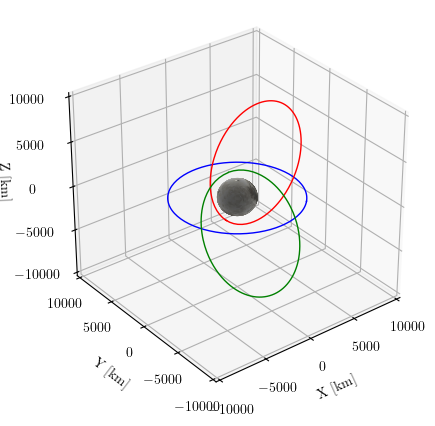

In [5]:
# Attitude
fig = pnt.plots.Plot3D(figsize=(5, 5), elev=31, azim=-128)
fig.plot_surface(pnt.MOON, scale=3)

# e_moon_sun = rv_moon_sun_mi[0, 0:3] / np.linalg.norm(rv_moon_sun_mi[0, 0:3])
# e_moon_earth = rv_moon_earth_mi[0, 0:3] / np.linalg.norm(rv_moon_earth_mi[0, 0:3])
orbit_color = np.array(["blue", "red", "green"])

for i_sat in range(N_sat):
    plt.plot(
        rv_moon_sat_mi[i_sat, :, 0],
        rv_moon_sat_mi[i_sat, :, 1],
        rv_moon_sat_mi[i_sat, :, 2],
        color=orbit_color[i_sat],
        linewidth=1,
    )



## Satellite Observables

In [4]:
def get_pseudorange_measurement(satpos, x_est, use_Gnoise):
    # simulate pseudorange measurements from a given satellite
    # likely inputs: true satellite state, true receiver state
    # we can already add noise to the measurements here, or outside like in the MATLAB simulator
    # the pseudorange error model is the same as what we had from the endurance work
    # also let's get the Jacobian here too (maybe JAX can come in handy!)
    
    # x_est is a 1x3 np array and satpos is a Nx3 np array
    n_meas = satpos.shape[0]
    los = np.tile(x_est, (n_meas, 1)) - satpos # Nx3
    range = np.linalg.norm(los, axis=1) # Nx1
    if use_Gnoise:
        Gnoise = np.random.normal(0.0, 1.0, size=n_meas)
        range += Gnoise
    print('los = ', los)
    print('range = ', range)
    print('tile = ', np.tile(range, (1, 3)))
    e = los / np.tile(range, (1, 3)) # Nx3
    H = e
    return range, H

def get_pseudorange_rate_measurement():
    # simulate pseudorange rate measurements from a given satellite
    # now the error model for this... is a little different and we need to think about it more
    # plus we need this for the ION paper too
    raise NotImplementedError

def get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi, fcar=2492.028e6, LNA_NF_dB = 1, rec_Tsys_K = 113):
    # assume that the satellite is always pointing towards the center of the moon
    # we are going to need some antenna gain patterns for this, but we can fish them out from the MATLAB simulator
    # simulate the carrier-to-noise ratio for a given satellite
    c = 299792458
    k_dBW_K_Hz = -228.6
    FSPL_dB = 20*np.log10(4*np.pi*dist_m*fcar/c)
    Prx = EIRP_beta_dBW - FSPL_dB
    Teq_K = rec_Tsys_K + 290*(10**(LNA_NF_dB/10)-1)
    Teq_dB = 10*np.log10(Teq_K)
    g_over_T = rec_gain_theta_dBi - Teq_dB
    cn0_dBHz = Prx + g_over_T - k_dBW_K_Hz
    cn0 = 10**(cn0_dBHz/10)
    return cn0

def mcmf_to_enu(lat_user, lon_user):
    # convert from MCMF to ENU coordinates
    # lat_user = rover latitude in radians (1x1)
    # lon_user = rover longitude in radians (1x1)
    phi, lmda = lat_user, lon_user
    M = np.array([
        [-np.sin(lmda), np.cos(lmda), 0],
        [-np.cos(lmda)*np.sin(phi), -np.sin(lmda)*np.sin(phi), np.cos(phi)],
        [np.cos(lmda)*np.cos(phi), np.sin(lmda)*np.cos(phi), np.sin(phi)]
    ])
    return M
    
def get_elev_azim(M, mcmf_sat, user_mcmf_rv, lent):
    # get the elevation and azimuth of a given satellite
    # M = output of mcmf_to_enu function (6x6)
    # mcmf_sat = Nx6 state vector of satellite (N is number of satellites)
    # user_mcmf_rv = 1x6 state vector of rover
    # lent = length of tspan (1x1)
    # Ensure user_mcmf_rv has the same size as mcmf_sat
    user_mcmf_rv = np.tile(user_mcmf_rv, (mcmf_sat.shape[0], 1))
    enu_sat = np.zeros(mcmf_sat.shape)
    # transform relative state to ENU frame for all satellites (Nx6)
    for i in range(mcmf_sat.shape[0]):
        enu_sat[i, :] = block_diag(M, M).dot(mcmf_sat[i, :] - user_mcmf_rv[i, :])
    el_sat, az_sat = np.zeros((lent, mcmf_sat.shape[0])), np.zeros((lent, mcmf_sat.shape[0]))
    # calculate elevation and azimuth for each time step and for each satellite
    for ii in range(lent):
        for sat_idx in range(mcmf_sat.shape[0]):
            norm_enu_sat = np.linalg.norm(enu_sat[sat_idx, :3])
            el_sat[ii, sat_idx] = np.degrees(np.arcsin(enu_sat[sat_idx, 2] / norm_enu_sat))  # up
            norm_east, norm_north = enu_sat[sat_idx, 0] / norm_enu_sat, enu_sat[sat_idx, 1] / norm_enu_sat
            az_sat_rad = np.mod(np.arctan2(norm_east, norm_north), 2 * np.pi)
            az_sat[ii, sat_idx] = np.degrees(az_sat_rad)
    return el_sat, az_sat

# TESTING
# Constants used for testing
EIRP_beta_dBW = 14
rec_gain_theta_dBi = 3
mcmf_sat = np.array([[-0.4513, 4.3380, -7.9516, -0.0005, -0.0001, 0.0],
                     [-0.4517, 4.3379, -7.9517, -0.0005, -0.0001, 0.0]]) * 1e3
user_mcmf_rv = np.array([0.0, 0.0, -1.7374, 0.0, 0.0, 0.0]) * 1e3
user_mcmf_rv = np.tile(user_mcmf_rv, (mcmf_sat.shape[0], 1))
lent = 2 #78047
lat_user = -1.5708
lon_user = 0.0

# print(mcmf_sat[:, :3].shape)
# print(user_mcmf_rv[0, :3])
# range, H = get_pseudorange_measurement(mcmf_sat[:, :3], user_mcmf_rv[0, :3], use_Gnoise = False)
# print('range = ', range)
# print('H = ', H)

dist_m = np.linalg.norm(mcmf_sat[:, :3] - user_mcmf_rv[:, :3], axis=1) * 1000
cn0 = get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi)
print(cn0)
print(dist_m)
print(mcmf_sat[:3])

M = mcmf_to_enu(lat_user, lon_user)
el_sat, az_sat = get_elev_azim(M, mcmf_sat, user_mcmf_rv, lent)
print(el_sat)
print(az_sat)

[30693.29485609 30692.90268395]
[7591982.43741383 7592030.93974201]
[[-4.5130e+02  4.3380e+03 -7.9516e+03 -5.0000e-01 -1.0000e-01  0.0000e+00]
 [-4.5170e+02  4.3379e+03 -7.9517e+03 -5.0000e-01 -1.0000e-01  0.0000e+00]]
[[54.93707351 54.93786569]
 [54.93707351 54.93786569]]
[[95.93905169 95.94441427]
 [95.93905169 95.94441427]]


# Rover

In [4]:
def p_norm_trajectory(x, p, a = 1, b = 1, c = 1):
    """ Generate a p-norm trajectory for given x values"""
    y_array = np.zeros(len(x))
    # solve for y
    for i in range(len(x)):
        y = sp.symbols('y')
        # p_norm equation
        y_array[i] = ((c**p - (x[i]/a)**p)**(1/p))*b
    # return y
    return y_array

def quad_trajectory(N, state_0, state_f, p):
    """ Generate a quadratic trajectory for 
    given x values based on p-norm approximation"""

    x0, y0, t0 = state_0
    xf, yf, tf = state_f

    eqn = lambda x : ((1**p - (x/xf)**p)**(1/p))*y0 - ((y0/xf)*x)
    alpha = sc.optimize.fsolve(eqn, xf/2)[0]

    A = np.zeros((6,6))
    poly_basis = lambda t_i :[1, t_i, t_i**2]

    A[0,0:3] = poly_basis(t0); A[1,3:] = poly_basis(t0);
    A[2,0:3] = poly_basis(tf); A[3,3:] = poly_basis(tf);
    A[4,0:3] = poly_basis(tf/2); A[5,3:] = poly_basis(tf/2);

    q = np.array([x0, y0, xf, yf, alpha, ((y0/xf)*alpha)])
    coeffs = np.linalg.solve(A, q)
    coeffs_x = coeffs[0:3]
    coeffs_y = coeffs[3:]

    # obtain the trajectory in terms of time
    traj = np.zeros((N, 2))
    t = np.linspace(t0, tf, N)
    for i in range(len(t)):
        x_t = np.dot(coeffs_x, poly_basis(t[i]))
        y_t = np.dot(coeffs_y, poly_basis(t[i]))

        traj[i,:] = [x_t, y_t]

    return coeffs, traj


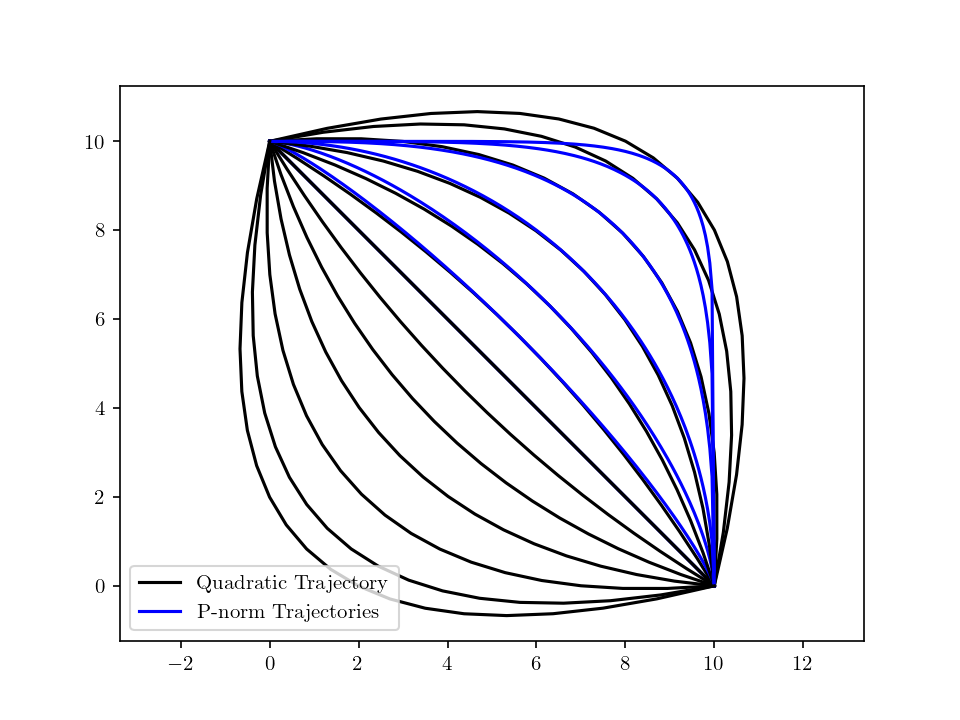

In [5]:
x0 = 0
y0 = 10
t0 = 0
xf = 10
yf = 0
tf = 10
t = np.linspace(t0, tf, 100)
x_list = np.linspace(x0, xf, 201)

state_0 = [x0, y0, t0]
state_f = [xf, yf, tf]
fig = plt.figure(dpi=150)
p_list = [1, 1.2, 1.5, 2, 3, 5, 8]
# p_list = [2]

# p_list = [1]
N = 21

for p in p_list:
    coeffs, traj = quad_trajectory(N, state_0, state_f, p)
    plt.plot(traj[:,0], traj[:,1], color='black', label = 'Quadratic Trajectory' if p == 1 else None)
    y = p_norm_trajectory(x_list, p, xf, y0, 1)
    # y_der = p_norm_derivative(x, p, a, b, c)
    plt.plot(x_list, y, color='blue', label = 'P-norm Trajectories' if p == 1 else None)
    # plt.plot(x, y_der, color='red')
    plt.plot(y0-traj[:,1], xf-traj[:,0], color='black')

# equal axis
# plt.plot([0,xf], [0, y0])
plt.legend()
plt.axis('equal');

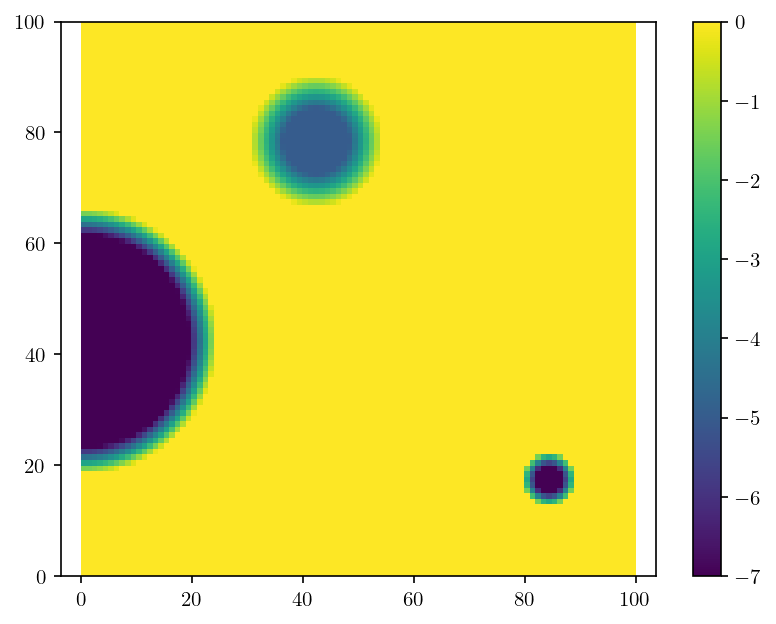

In [76]:
# create a grid
grid_env = grid_world.GridWorld()
# if you want to get the grid, use
# grid = grid_env.grid()

# let's add some craters (if you do not specify location, they will be randomly placed)
crater = grid_env.create_crater(12, 5)
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(5, 7)
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(24, 7)
grid_env.add_crater(crater, slope_factor=0.8)

# plot the grid
grid_env.plot_grid()

## Analysis of GDOP, Visibility, Ground Track, etc...

In [6]:
def get_GDOP():
    # A function that computes the GDOP of a given set of satellites at a single time instance
    raise NotImplementedError

def plot_ground_track():
    # A function that plots the ground track of the satellites
    # Marta: I will migrate this from the MATLAB simulator, I have the code for it
    raise NotImplementedError